# Improved Ensemble with Hill Climbing

This notebook uses **Hill Climbing** optimization (Forward Selection) to build a robust ensemble.

**Features:**
- **Flexible Config**: Configuration from global config.yml.
- **Deep Analysis**: Correlation Matrix, Overlap Analysis, and Exclusive Contributions.
- **Hill Climbing**: Iteratively adds models that maximize F1 Score, compared against a Baseline.

In [1]:
import sys
sys.path.insert(0, '..')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, f1_score
import warnings

from src.config_loader import load_config, get_path, get_seed, get_model_config, get

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [2]:
# Configuration from global config.yml
config = load_config()
RANDOM_STATE = get_seed()

# Paths from global config.yml
DATA_DIR = get_path('data_processed')
MODEL_DIR = get_path('models')
SUBMISSION_DIR = get_path('submissions')
RAW_DIR = get_path('data_raw')

FOLDS_PATH = DATA_DIR / 'train_folds.csv'
TEST_RAW_PATH = RAW_DIR / 'test_log.csv'

os.makedirs(SUBMISSION_DIR, exist_ok=True)

local_fallback_models = ['xgb', 'lgb', 'cat', 'mlp', 'resnet']

# Attempt to get the list from config.yml
config_models = get('ensemble', {}).get('include_models', [])

if config_models:
    MODEL_NAMES = config_models
    print(f"Using ensemble list from config.yml: {MODEL_NAMES}")
else:
    MODEL_NAMES = local_fallback_models
    print(f"Config list empty or missing. Using local fallback: {MODEL_NAMES}")

Using ensemble list from config.yml: ['xgb', 'lgb', 'cat', 'tabpfn', 'mlp', 'resnet', 'et', 'ft_transformer']


In [3]:
# Load ground truth
print("Loading ground truth and predictions...")
folds_df = pd.read_csv(FOLDS_PATH)
print(f"Folds shape: {folds_df.shape}")

# Load OOF predictions
oof_dfs = {}
for name in MODEL_NAMES:
    path = MODEL_DIR / f'oof_{name}.csv'
    if path.exists():
        oof_dfs[name] = pd.read_csv(path)
        print(f"Loaded OOF {name}: {oof_dfs[name].shape}")
    else:
        print(f"Warning: {path} not found, skipping {name}")

# Load Test predictions
test_dfs = {}
for name in MODEL_NAMES:
    path = MODEL_DIR / f'preds_{name}.csv'
    if path.exists():
        test_dfs[name] = pd.read_csv(path)
        print(f"Loaded Test {name}: {test_dfs[name].shape}")
    else:
        print(f"Warning: {path} not found, skipping {name}")

# Update MODEL_NAMES to only include available models
MODEL_NAMES = [name for name in MODEL_NAMES if name in oof_dfs and name in test_dfs]
print(f"\nAvailable models for ensemble: {MODEL_NAMES}")

Loading ground truth and predictions...
Folds shape: (3043, 3)
Loaded OOF xgb: (3043, 3)
Loaded OOF lgb: (3043, 3)
Loaded OOF cat: (3043, 3)
Loaded OOF tabpfn: (3043, 3)
Loaded OOF mlp: (3043, 3)
Loaded OOF resnet: (3043, 3)
Loaded OOF et: (3043, 3)
Loaded OOF ft_transformer: (3043, 3)
Loaded Test xgb: (7135, 2)
Loaded Test lgb: (7135, 2)
Loaded Test cat: (7135, 2)
Loaded Test tabpfn: (7135, 2)
Loaded Test mlp: (7135, 2)
Loaded Test resnet: (7135, 2)
Loaded Test et: (7135, 2)
Loaded Test ft_transformer: (7135, 2)

Available models for ensemble: ['xgb', 'lgb', 'cat', 'tabpfn', 'mlp', 'resnet', 'et', 'ft_transformer']


In [4]:
# Merge OOF predictions on object_id
print("\nMerging OOF predictions...")
oof_merged = folds_df[['object_id', 'target']].copy()

for name in MODEL_NAMES:
    pred_col = f'pred_{name}'
    oof_merged = oof_merged.merge(
        oof_dfs[name][['object_id', pred_col]], 
        on='object_id', 
        how='left'
    )

print(f"Merged OOF shape: {oof_merged.shape}")
print(f"Columns: {oof_merged.columns.tolist()}")

# Merge Test predictions on object_id
print("\nMerging Test predictions...")
test_merged = test_dfs[MODEL_NAMES[0]][['object_id']].copy()

for name in MODEL_NAMES:
    pred_col = f'pred_{name}'
    test_merged = test_merged.merge(
        test_dfs[name][['object_id', pred_col]], 
        on='object_id', 
        how='left'
    )

print(f"Merged Test shape: {test_merged.shape}")
print(f"Columns: {test_merged.columns.tolist()}")


Merging OOF predictions...
Merged OOF shape: (3043, 10)
Columns: ['object_id', 'target', 'pred_xgb', 'pred_lgb', 'pred_cat', 'pred_tabpfn', 'pred_mlp', 'pred_resnet', 'pred_et', 'pred_ft_transformer']

Merging Test predictions...
Merged Test shape: (7135, 9)
Columns: ['object_id', 'pred_xgb', 'pred_lgb', 'pred_cat', 'pred_tabpfn', 'pred_mlp', 'pred_resnet', 'pred_et', 'pred_ft_transformer']


In [5]:
# Prepare arrays for optimization
y_true = oof_merged['target'].values
oof_preds = np.column_stack([oof_merged[f'pred_{name}'].values for name in MODEL_NAMES])
test_preds = np.column_stack([test_merged[f'pred_{name}'].values for name in MODEL_NAMES])

print(f"Target shape: {y_true.shape}")
print(f"OOF predictions shape: {oof_preds.shape}")
print(f"Test predictions shape: {test_preds.shape}")
print(f"\nClass distribution: {np.bincount(y_true.astype(int))}")

Target shape: (3043,)
OOF predictions shape: (3043, 8)
Test predictions shape: (7135, 8)

Class distribution: [2895  148]



=== Model Correlation Analysis ===



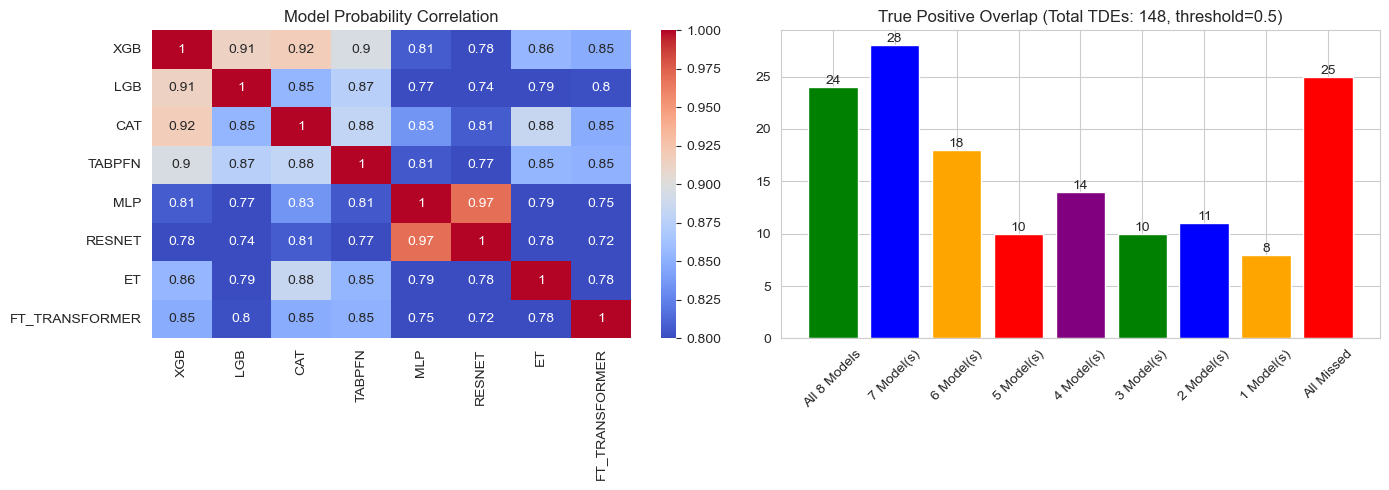

--- Overlap Insights ---
If lower model counts have high values, your models find DIFFERENT TDEs (Ensemble helps a lot).
If 'All N Models' is high, your models are similar (Ensemble will stabilize but boost less).


In [6]:
# Model Correlation Analysis
print("\n=== Model Correlation Analysis ===\n")

# Create probability DataFrame
probs_df = pd.DataFrame({name.upper(): oof_merged[f'pred_{name}'].values for name in MODEL_NAMES})

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 1. Correlation Heatmap (Probability Rank Alignment) ---
sns.heatmap(probs_df.corr(), annot=True, cmap='coolwarm', vmin=0.8, vmax=1.0, ax=axes[0])
axes[0].set_title('Model Probability Correlation')

# --- 2. Binary Overlap (Decision Agreement) ---
temp_threshold = 0.5
binary_df = pd.DataFrame({name.upper(): (oof_merged[f'pred_{name}'].values >= temp_threshold).astype(int) for name in MODEL_NAMES})
binary_df['Sum'] = binary_df.sum(axis=1)
binary_df['Target'] = y_true

# Count overlaps for true positives
n_models = len(MODEL_NAMES)
overlap_counts = []
categories = []
colors = ['green', 'blue', 'orange', 'red', 'purple'][:n_models + 1]

for i in range(n_models, -1, -1):
    count = len(binary_df[(binary_df['Sum'] == i) & (binary_df['Target'] == 1)])
    overlap_counts.append(count)
    if i == n_models:
        categories.append(f'All {n_models} Models')
    elif i == 0:
        categories.append('All Missed')
    else:
        categories.append(f'{i} Model(s)')

bars = axes[1].bar(categories, overlap_counts, color=colors[:len(categories)])
axes[1].set_title(f'True Positive Overlap (Total TDEs: {int(y_true.sum())}, threshold=0.5)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].bar_label(bars)

plt.tight_layout()
plt.show()

print("--- Overlap Insights ---")
print("If lower model counts have high values, your models find DIFFERENT TDEs (Ensemble helps a lot).")
print("If 'All N Models' is high, your models are similar (Ensemble will stabilize but boost less).")

In [7]:
# Print models in each category for better interpretation
print("\n=== Models in Each Category ===\n")

temp_threshold = 0.5
model_cols = [name.upper() for name in MODEL_NAMES]
binary_analysis_df = pd.DataFrame({name.upper(): (oof_merged[f'pred_{name}'].values >= temp_threshold).astype(int) for name in MODEL_NAMES})
binary_analysis_df['Sum'] = binary_analysis_df[model_cols].sum(axis=1)
binary_analysis_df['Target'] = y_true

n_models = len(MODEL_NAMES)

# For each category (from n_models down to 0)
for i in range(n_models, -1, -1):
    subset = binary_analysis_df[(binary_analysis_df['Sum'] == i) & (binary_analysis_df['Target'] == 1)]
    count = len(subset)
    
    if i == n_models:
        cat_name = f"All {n_models} Models"
    elif i == 0:
        cat_name = "All Missed (0 models)"
    else:
        cat_name = f"Only {i} model(s)"
    
    print(f"--- {cat_name}: {count} TDEs ---")
    
    if count > 0 and i > 0:
        model_detection_counts = {}
        for model_name in model_cols:
            model_detection_counts[model_name] = subset[model_name].sum()
        
        sorted_models = sorted(model_detection_counts.items(), key=lambda x: x[1], reverse=True)
        
        combo_counts = {}
        for idx, row in subset.iterrows():
            detecting_models = tuple(sorted([m for m in model_cols if row[m] == 1]))
            combo_counts[detecting_models] = combo_counts.get(detecting_models, 0) + 1
        
        sorted_combos = sorted(combo_counts.items(), key=lambda x: x[1], reverse=True)
        for combo, combo_count in sorted_combos:
            combo_str = ', '.join(combo) if combo else 'None'
            print(f"  [{combo_str}]: {combo_count} TDEs")
    elif i == 0:
        print(f"  No model detected these {count} TDEs")
    
    print()


=== Models in Each Category ===

--- All 8 Models: 24 TDEs ---
  [CAT, ET, FT_TRANSFORMER, LGB, MLP, RESNET, TABPFN, XGB]: 24 TDEs

--- Only 7 model(s): 28 TDEs ---
  [CAT, FT_TRANSFORMER, LGB, MLP, RESNET, TABPFN, XGB]: 16 TDEs
  [CAT, ET, FT_TRANSFORMER, LGB, MLP, RESNET, XGB]: 6 TDEs
  [CAT, ET, FT_TRANSFORMER, LGB, MLP, TABPFN, XGB]: 4 TDEs
  [CAT, ET, FT_TRANSFORMER, MLP, RESNET, TABPFN, XGB]: 1 TDEs
  [CAT, ET, LGB, MLP, RESNET, TABPFN, XGB]: 1 TDEs

--- Only 6 model(s): 18 TDEs ---
  [CAT, ET, FT_TRANSFORMER, LGB, TABPFN, XGB]: 5 TDEs
  [CAT, FT_TRANSFORMER, LGB, MLP, RESNET, XGB]: 3 TDEs
  [CAT, ET, FT_TRANSFORMER, MLP, RESNET, XGB]: 2 TDEs
  [CAT, FT_TRANSFORMER, LGB, MLP, TABPFN, XGB]: 2 TDEs
  [CAT, FT_TRANSFORMER, MLP, RESNET, TABPFN, XGB]: 2 TDEs
  [CAT, ET, FT_TRANSFORMER, LGB, MLP, XGB]: 2 TDEs
  [CAT, ET, FT_TRANSFORMER, LGB, MLP, RESNET]: 1 TDEs
  [CAT, FT_TRANSFORMER, LGB, MLP, RESNET, TABPFN]: 1 TDEs

--- Only 5 model(s): 10 TDEs ---
  [CAT, ET, FT_TRANSFORMER, LGB,

In [8]:
def get_f1(y_true, y_pred):
    """Calculate F1 at optimal threshold."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_pred)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
    return np.max(f1_scores)

def hill_climbing(oof_preds, models, y_true, iterations=100):
    """
    Iteratively add models to the ensemble to maximize F1 Score.
    
    Args:
        oof_preds: numpy array of shape (n_samples, n_models)
        models: list of model names
        y_true: ground truth labels
        iterations: number of iterations
    """
    current_preds = np.zeros_like(y_true, dtype=float)
    best_score = -1
    model_counts = {m: 0 for m in models}
    history = []
    
    # Find best single model start
    best_single_model = None
    best_single_idx = None
    for idx, m in enumerate(models):
        score = get_f1(y_true, oof_preds[:, idx])
        if score > best_score:
            best_score = score
            best_single_model = m
            best_single_idx = idx
            current_preds = oof_preds[:, idx].copy()
            
    model_counts[best_single_model] += 1
    history.append(best_score)
    print(f"Start with Best Single Model: {best_single_model} (F1: {best_score:.5f})")
    
    # Iteratively add models
    for i in range(1, iterations):
        stack_best_score = -1
        stack_best_model = None
        stack_best_idx = None
        
        for idx, m in enumerate(models):
            temp_preds = (current_preds * i + oof_preds[:, idx]) / (i + 1)
            score = get_f1(y_true, temp_preds)
            
            if score > stack_best_score:
                stack_best_score = score
                stack_best_model = m
                stack_best_idx = idx
        
        # Update state
        if stack_best_score > best_score:
            best_score = stack_best_score
            current_preds = (current_preds * i + oof_preds[:, stack_best_idx]) / (i + 1)
            model_counts[stack_best_model] += 1
            history.append(best_score)
            if i % 10 == 0 or i < 5:
                print(f"Iter {i}: Added {stack_best_model}, New Best F1: {best_score:.5f}")
        else:
            current_preds = (current_preds * i + oof_preds[:, stack_best_idx]) / (i + 1)
            model_counts[stack_best_model] += 1
            history.append(best_score)
            
    # Normalize weights
    total = sum(model_counts.values())
    weights = {m: c / total for m, c in model_counts.items()}
    return weights, best_score, current_preds, history


=== Running Hill Climbing Optimization ===

Baseline (Simple Average) F1: 0.70517
Start with Best Single Model: cat (F1: 0.70154)
Iter 1: Added resnet, New Best F1: 0.70968
Iter 2: Added ft_transformer, New Best F1: 0.71827
Iter 3: Added tabpfn, New Best F1: 0.72050
Iter 4: Added xgb, New Best F1: 0.72100

Final Weights:
  TABPFN: 0.2600
  FT_TRANSFORMER: 0.2000
  CAT: 0.1800
  XGB: 0.1300
  MLP: 0.1300
  RESNET: 0.0600
  LGB: 0.0400

Best Local F1: 0.73585


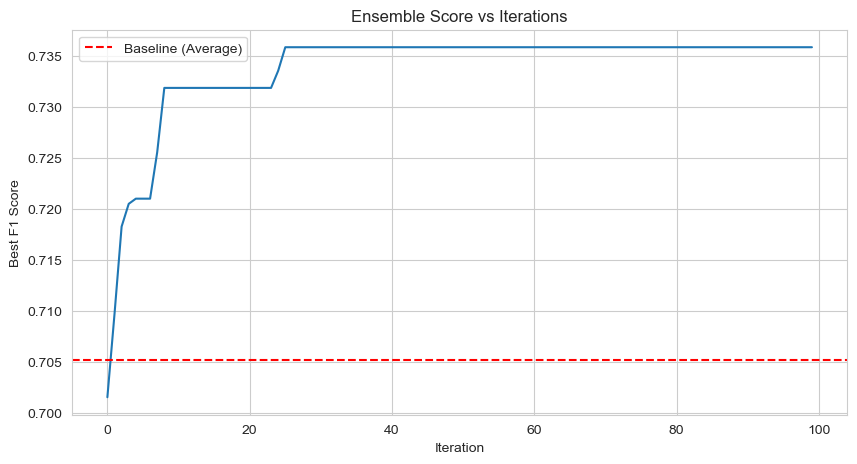

In [9]:
print("\n=== Running Hill Climbing Optimization ===\n")

# Baseline: Simple Average
baseline_preds = oof_preds.mean(axis=1)
baseline_f1 = get_f1(y_true, baseline_preds)
print(f"Baseline (Simple Average) F1: {baseline_f1:.5f}")

# Run Optimization
np.random.seed(RANDOM_STATE)
weights, best_f1, best_preds, history = hill_climbing(oof_preds, MODEL_NAMES, y_true, iterations=100)

print("\nFinal Weights:")
sorted_weights = sorted(weights.items(), key=lambda x: x[1], reverse=True)
for m, w in sorted_weights:
    if w > 0:
        print(f"  {m.upper()}: {w:.4f}")
        
print(f"\nBest Local F1: {best_f1:.5f}")

# History Plot
plt.figure(figsize=(10, 5))
plt.plot(history)
plt.axhline(y=baseline_f1, color='r', linestyle='--', label='Baseline (Average)')
plt.title('Ensemble Score vs Iterations')
plt.xlabel('Iteration')
plt.ylabel('Best F1 Score')
plt.legend()
plt.show()

In [10]:
# Optimize threshold
print("\n=== Optimizing Threshold (Maximize F1 Score) ===")

# Method 1: Using precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_true, best_preds)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold_prc = thresholds[best_idx]
best_f1_prc = f1_scores[best_idx]

print(f"\nMethod 1 (Precision-Recall Curve):")
print(f"  Best Threshold: {best_threshold_prc:.4f}")
print(f"  Best F1 Score: {best_f1_prc:.4f}")

# Method 2: Grid search from 0.01 to 0.99
thresholds_grid = np.arange(0.01, 0.99, 0.01)
f1_grid = []

for thresh in thresholds_grid:
    preds_binary = (best_preds >= thresh).astype(int)
    f1 = f1_score(y_true, preds_binary)
    f1_grid.append(f1)

best_idx_grid = np.argmax(f1_grid)
best_threshold_grid = thresholds_grid[best_idx_grid]
best_f1_grid = f1_grid[best_idx_grid]

print(f"\nMethod 2 (Grid Search):")
print(f"  Best Threshold: {best_threshold_grid:.4f}")
print(f"  Best F1 Score: {best_f1_grid:.4f}")

if best_f1_prc >= best_f1_grid:
    best_threshold = best_threshold_prc
    final_f1 = best_f1_prc
    print(f"\nUsing Precision-Recall Curve threshold.")
else:
    best_threshold = best_threshold_grid
    final_f1 = best_f1_grid
    print(f"\nUsing Grid Search threshold.")

print(f"\n=== Final Selected Threshold: {best_threshold:.4f} ===")
print(f"=== Final F1 Score (OOF): {final_f1:.4f} ===")


=== Optimizing Threshold (Maximize F1 Score) ===

Method 1 (Precision-Recall Curve):
  Best Threshold: 0.3689
  Best F1 Score: 0.7358

Method 2 (Grid Search):
  Best Threshold: 0.3700
  Best F1 Score: 0.7278

Using Precision-Recall Curve threshold.

=== Final Selected Threshold: 0.3689 ===
=== Final F1 Score (OOF): 0.7358 ===



=== Binary Overlap with Optimal Threshold ===


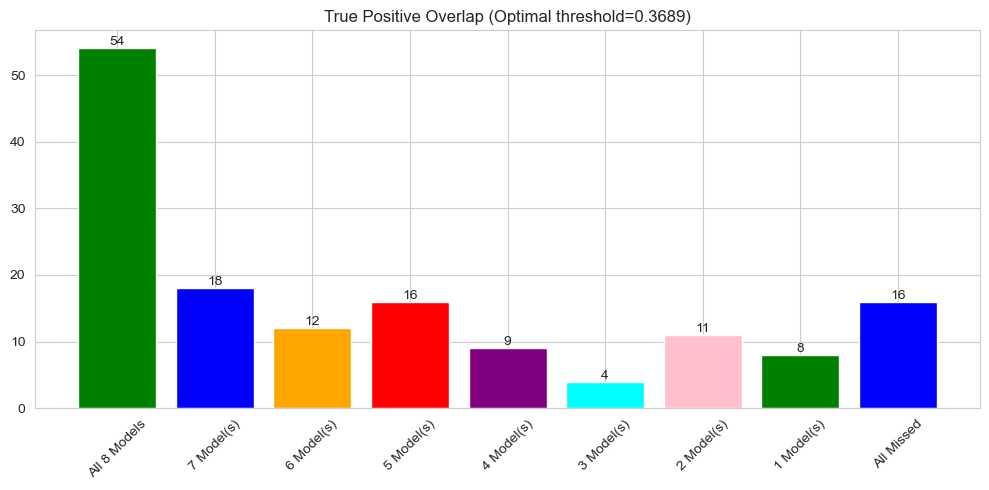

In [11]:
# Visualize overlap with optimal threshold
print("\n=== Binary Overlap with Optimal Threshold ===")

binary_df_opt = pd.DataFrame({name.upper(): (oof_merged[f'pred_{name}'].values >= best_threshold).astype(int) for name in MODEL_NAMES})
binary_df_opt['Sum'] = binary_df_opt.sum(axis=1)
binary_df_opt['Target'] = y_true

n_models = len(MODEL_NAMES)
overlap_counts_opt = []
categories_opt = []
colors_opt = ['green', 'blue', 'orange', 'red', 'purple', 'cyan', 'pink'][:n_models + 1]

for i in range(n_models, -1, -1):
    count = len(binary_df_opt[(binary_df_opt['Sum'] == i) & (binary_df_opt['Target'] == 1)])
    overlap_counts_opt.append(count)
    if i == n_models:
        categories_opt.append(f'All {n_models} Models')
    elif i == 0:
        categories_opt.append('All Missed')
    else:
        categories_opt.append(f'{i} Model(s)')

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(categories_opt, overlap_counts_opt, color=colors_opt[:len(categories_opt)])
ax.set_title(f'True Positive Overlap (Optimal threshold={best_threshold:.4f})')
ax.tick_params(axis='x', rotation=45)
ax.bar_label(bars)
plt.tight_layout()
plt.show()

In [12]:
# Generate Final Submission
print("\n=== Generating Final Submission ===")

# Calculate weighted test predictions using hill climbing weights
optimal_weights = np.array([weights[name] for name in MODEL_NAMES])
weighted_test = np.sum(test_preds * optimal_weights, axis=1)
test_labels = (weighted_test >= best_threshold).astype(int)

submission = pd.DataFrame({
    'object_id': test_merged['object_id'],
    'target': test_labels
})

print(f"Submission shape: {submission.shape}")
print(f"Predicted distribution: {np.bincount(test_labels)}")
print(f"Positive rate: {test_labels.sum() / len(test_labels):.4f}")

submission_path = SUBMISSION_DIR / 'submission_ensemble2.csv'
submission.to_csv(submission_path, index=False)
print(f"\nSubmission saved to: {submission_path}")


=== Generating Final Submission ===
Submission shape: (7135, 2)
Predicted distribution: [6757  378]
Positive rate: 0.0530

Submission saved to: d:\MALLORN Private\notebooks\..\submissions\submission_ensemble2.csv


In [13]:
# Summary
print("\n" + "="*50)
print(" HILL CLIMBING ENSEMBLE SUMMARY")
print("="*50)
print(f"\nModels used: {MODEL_NAMES}")
print(f"\nOptimal Weights (Hill Climbing):")
for name, weight in sorted(weights.items(), key=lambda x: x[1], reverse=True):
    if weight > 0:
        print(f"  {name.upper()}: {weight:.4f}")
print(f"\nOptimal Threshold: {best_threshold:.4f}")
print(f"OOF F1 Score: {final_f1:.4f}")
print(f"Baseline F1 (Simple Average): {baseline_f1:.4f}")
print(f"\nTest Predictions:")
print(f"  Total samples: {len(submission)}")
print(f"  Predicted TDEs: {test_labels.sum()}")
print(f"  Positive rate: {test_labels.sum() / len(test_labels):.4f}")
print("="*50)


 HILL CLIMBING ENSEMBLE SUMMARY

Models used: ['xgb', 'lgb', 'cat', 'tabpfn', 'mlp', 'resnet', 'et', 'ft_transformer']

Optimal Weights (Hill Climbing):
  TABPFN: 0.2600
  FT_TRANSFORMER: 0.2000
  CAT: 0.1800
  XGB: 0.1300
  MLP: 0.1300
  RESNET: 0.0600
  LGB: 0.0400

Optimal Threshold: 0.3689
OOF F1 Score: 0.7358
Baseline F1 (Simple Average): 0.7052

Test Predictions:
  Total samples: 7135
  Predicted TDEs: 378
  Positive rate: 0.0530
